# 2.2  Deep Dive: Spatial Mapping & Cleanup Rationale

This notebook **justifies every spatial cleanup decision** taken in `01_Preprocessing/01_04_Trip_Data_Cleanup.ipynb` using maps and counts, and finishes with a side-by-side comparison of the two ways to build the H3 grid:
**direct centroid mapping** vs the **area-weighted** approach.

It works directly on the raw trip file (`01_01_fetch_trip_data.parquet`, 6.8M rows) so the problems — and the fixes — are visible from scratch. Reference geometry comes from `tl_2010_17031_tract10` (2010 census tracts) and `Boundaries_Community_Areas_20260608.geojson` (the 77 community areas).

### Data Requirements:

This notebook requires the following files: 

1. `tl_2010_17031_tract10.shp` — local path: `data/geometry/tl_2010_17031_tract10/tl_2010_17031_tract10.shp` — Sciebo path: `data_parquet/geometry/tl_2010_17031_tract10/tl_2010_17031_tract10.shp`

2. `Census_Tracts_Chicago.geojson` — local path: `data/geometry/Census_Tracts_Chicago.geojson` — Sciebo path: `data_parquet/geometry/Census_Tracts_Chicago.geojson`

3. `Boundaries_Community_Areas_20260608.geojson` — local path: `data/geometry/Boundaries_Community_Areas_20260608.geojson` — Sciebo path: `data_parquet/geometry/Boundaries_Community_Areas_20260608.geojson`

4. `01_01_fetch_trip_data.parquet` — local path: `data/trips/01_01_fetch_trip_data.parquet` — Sciebo path: `data_parquet/trips/01_01_fetch_trip_data.parquet`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [9]:
import pandas as pd
import numpy as np
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Polygon, Point

import os
from pathlib import Path

In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA


In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reference geometries + crosswalk        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# 2010 census tracts (the vintage the taxi data uses), Cook County only
tracts2010 = (gpd.read_file("data/geometry/tl_2010_17031_tract10/tl_2010_17031_tract10.shp")
              .rename(columns={"GEOID10": "GEOID"}).to_crs(4326))
tracts2010["GEOID"] = tracts2010["GEOID"].astype(str)

# 2000-vintage tracts shipped earlier in the project
tracts2000 = (gpd.read_file("data/geometry/Census_Tracts_Chicago.geojson")
              .rename(columns={"census_t_1": "GEOID"}).to_crs(4326))
tracts2000["GEOID"] = tracts2000["GEOID"].astype(str)

# Official 77 community areas
community_areas = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(4326)
community_areas["community_area"] = community_areas["area_numbe"].astype(int)
community_areas = community_areas[["community_area", "community", "geometry"]]

# City outline = union of all community areas
city_poly = community_areas.geometry.union_all()

# tract -> community area crosswalk by LARGEST area of overlap.
# (A simple "interior point within a community area" test misclassifies lakefront
# tracts, whose interior point sits in Lake Michigan -- the community-area polygons
# stop at the shoreline. Largest-overlap is robust to that.)
_tr_m = tracts2010[["GEOID", "geometry"]].to_crs(26971)
_tract_area = _tr_m.set_index("GEOID").geometry.area
_ca_m = community_areas[["community_area", "geometry"]].to_crs(26971)
_ov = gpd.overlay(_tr_m, _ca_m, how="intersection", keep_geom_type=True)
_ov["a"] = _ov.geometry.area
_best = _ov.loc[_ov.groupby("GEOID")["a"].idxmax()].copy()
_best["frac"] = _best["a"].values / _best["GEOID"].map(_tract_area).values
# keep a tract as "in city" only if a community area covers >10% of it
# (excludes suburban tracts that merely clip a border community area)
_best = _best[_best["frac"] > 0.10]
tract_to_ca = dict(zip(_best["GEOID"], _best["community_area"]))
in_city_2010 = set(tract_to_ca)

print(f"2010 tracts: {len(tracts2010)}  (inside Chicago: {len(in_city_2010)})")
print(f"2000 tracts (geojson): {len(tracts2000)}")
print(f"Community areas: {len(community_areas)}")

2010 tracts: 1319  (inside Chicago: 799)
2000 tracts (geojson): 878
Community areas: 77


In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load raw trips (location columns)       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LOC_COLS = ["pickup_census_tract", "dropoff_census_tract",
            "pickup_community_area", "dropoff_community_area",
            "pickup_centroid_latitude", "pickup_centroid_longitude",
            "dropoff_centroid_latitude", "dropoff_centroid_longitude"]

df = pd.read_parquet("data/trips/01_01_fetch_trip_data.parquet", columns=["trip_id"] + LOC_COLS)

# census tract: float (1.7031e10) / NaN  ->  clean GEOID string / <NA>
def to_geoid(s):
    return pd.to_numeric(s, errors="coerce").astype("Int64").astype("string")
df["pickup_census_tract"]  = to_geoid(df["pickup_census_tract"])
df["dropoff_census_tract"] = to_geoid(df["dropoff_census_tract"])

# the set of tracts that actually appear in the data (2010 GEOIDs)
taxi_tracts = set(df["pickup_census_tract"].dropna()) | set(df["dropoff_census_tract"].dropna())

print(f"Raw trips: {len(df):,}")
df.head()

Raw trips: 6,825,838


,trip_id,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,<NA>,<NA>,8.0,8.0,41.899602,-87.633308,41.899602,-87.633308
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,<NA>,<NA>,76.0,6.0,41.980264,-87.913625,41.944227,-87.655998
2,060f692c4ca69e552c07a97c99715ad51112470e,<NA>,<NA>,6.0,6.0,41.944227,-87.655998,41.944227,-87.655998
3,0b2d1368456148b049af41dc8aa565d688081756,<NA>,<NA>,77.0,77.0,41.986712,-87.663416,41.986712,-87.663416
4,17365c83264f028a307ac70308d770fe03bcbcae,<NA>,<NA>,8.0,7.0,41.899602,-87.633308,41.922686,-87.649489


## 1  Two location resolutions live in this dataset

Every trip endpoint is reported at **one of two spatial resolutions**, never both reliably:

* a **census tract** (~0.3 km², the precise level), or
* only a **community area** (~3 km², one of Chicago's 77 neighbourhoods).

Chicago suppresses the census tract whenever revealing it would identify too few trips, and falls back to the community-area centroid. Before we can put trips on a common grid we must *measure* how much of the data sits at each resolution — that decision drives every later step.

                       pickup %  dropoff %
has census tract          45.12      43.83
has community area        97.26      91.40
has coordinates           97.31      91.90
tract-level (precise)     45.12      43.83
community-area only       52.20      48.17
no location at all         2.67       8.00


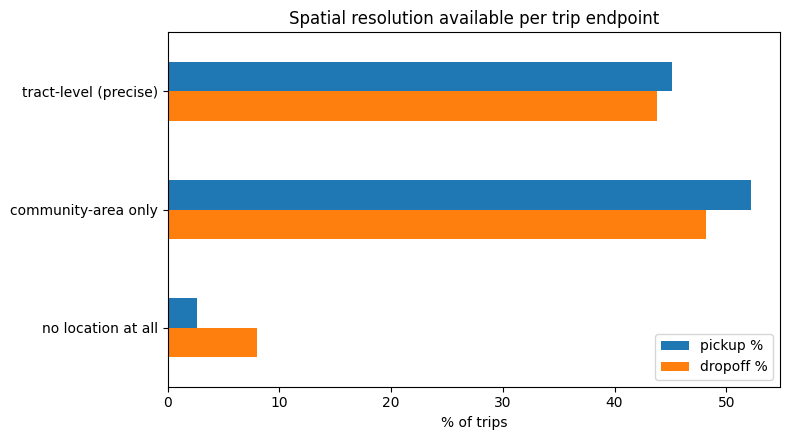

In [13]:
def coverage_table(prefix):
    tract = df[f"{prefix}_census_tract"].notna()
    ca    = df[f"{prefix}_community_area"].notna()
    coord = df[f"{prefix}_centroid_latitude"].notna()
    return pd.Series({
        "has census tract":      tract.mean() * 100,
        "has community area":    ca.mean() * 100,
        "has coordinates":       coord.mean() * 100,
        "tract-level (precise)": tract.mean() * 100,
        "community-area only":   (ca & ~tract).mean() * 100,
        "no location at all":    (~tract & ~ca & ~coord).mean() * 100,
    }).round(2)

cov = pd.DataFrame({"pickup %": coverage_table("pickup"),
                    "dropoff %": coverage_table("dropoff")})
print(cov)

fig, ax = plt.subplots(figsize=(8, 4.5))
rows = ["tract-level (precise)", "community-area only", "no location at all"]
cov.loc[rows].plot(kind="barh", ax=ax)
ax.set_xlabel("% of trips")
ax.set_title("Spatial resolution available per trip endpoint")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Reading.** Only ~45 % of endpoints carry a precise census tract; ~52 % are community-area
only; a few percent have nothing. Two consequences:

1. We cannot build a *tract* grid from tract IDs alone — that throws away half the trips, and the
   discarded half is **not random** (suppression hits low-volume areas, biasing toward downtown).
2. The **community area** is the finest level present for almost every trip, which is why it
   becomes our common spatial unit.

## 2  Which census-tract vintage? (the 2000 vs 2010 trap)

The trip records use **2010** census-tract IDs. The project also ships `Census_Tracts_Chicago.geojson`, but that file is **2000 vintage**. Joining 2010 IDs to 2000 geometry silently fails for every tract renumbered between censuses. We expose the damage by colouring, in each tract layer, the tracts whose GEOID actually appears in the trip data.

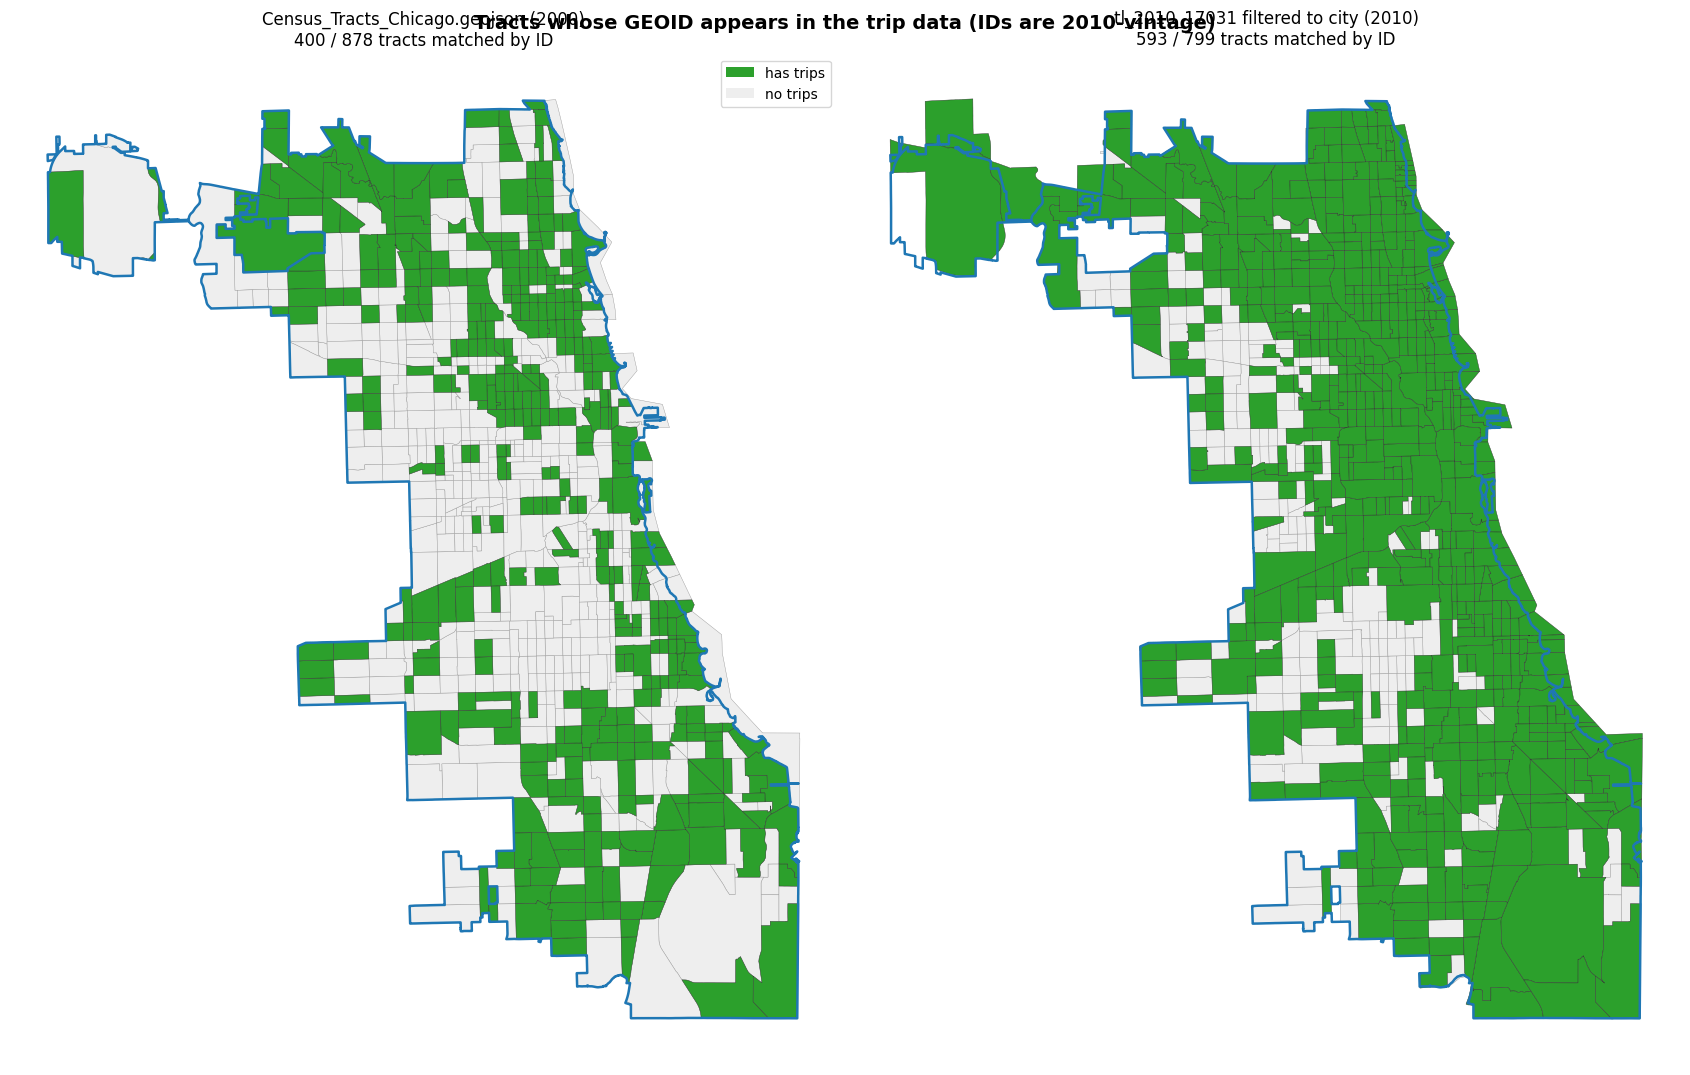

In [14]:
t2010_city = tracts2010[tracts2010["GEOID"].isin(in_city_2010)].copy()
t2010_city["has_trips"] = t2010_city["GEOID"].isin(taxi_tracts)
t2000 = tracts2000.copy()
t2000["has_trips"] = t2000["GEOID"].isin(taxi_tracts)

fig, axes = plt.subplots(1, 2, figsize=(17, 11))
for ax, gdf, title in [
    (axes[0], t2000,
     f"Census_Tracts_Chicago.geojson (2000)\n{int(t2000.has_trips.sum())} / {len(t2000)} tracts matched by ID"),
    (axes[1], t2010_city,
     f"tl_2010_17031 filtered to city (2010)\n{int(t2010_city.has_trips.sum())} / {len(t2010_city)} tracts matched by ID"),
]:
    gdf[~gdf.has_trips].plot(ax=ax, facecolor="#eeeeee", edgecolor="#999999", linewidth=0.3)
    gdf[gdf.has_trips].plot(ax=ax, facecolor="#2ca02c", edgecolor="#333333", linewidth=0.3)
    gpd.GeoSeries([city_poly], crs=4326).plot(ax=ax, facecolor="none", edgecolor="#1f77b4", linewidth=1.8)
    ax.set_title(title, fontsize=12); ax.set_axis_off()
axes[0].legend(handles=[Patch(facecolor="#2ca02c", label="has trips"),
                        Patch(facecolor="#eeeeee", label="no trips")], loc="upper right")
plt.suptitle("Tracts whose GEOID appears in the trip data (IDs are 2010-vintage)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

**Reading.** The 2010 layer fills in as a *coherent* region — the only gaps are genuinely low-activity tracts on the far South / South-West Side. The 2000 layer is full of **scattered** gaps in obviously busy areas: those are not "no trips", they are **ID-match failures** from the vintage mismatch. Matching to the 2000 file silently drops ~190 tracts of coverage. 
→ **We join trips to the 2010 tracts.**

## 3  Drop unusable and out-of-city trips

Two *separate* removals happen here, and it is important not to confuse them:

* **Step 1 — no usable location.** A trip endpoint with no census tract, no community area *and* no
  coordinate cannot be placed anywhere. These are dropped first — they are *unusable*, not "outside".
* **Step 2 — outside the city.** Of the trips that remain, some start or end in **suburban Cook
  County** (tract codes 77xx / 8xxx). Community areas exist only inside the city, so an endpoint is
  *inside Chicago* when it has a community area, when its 2010 tract maps to a community area, or
  when its coordinate lies within the city outline.

The map shows the suburban tracts that appear in the data; the counts below report both steps.

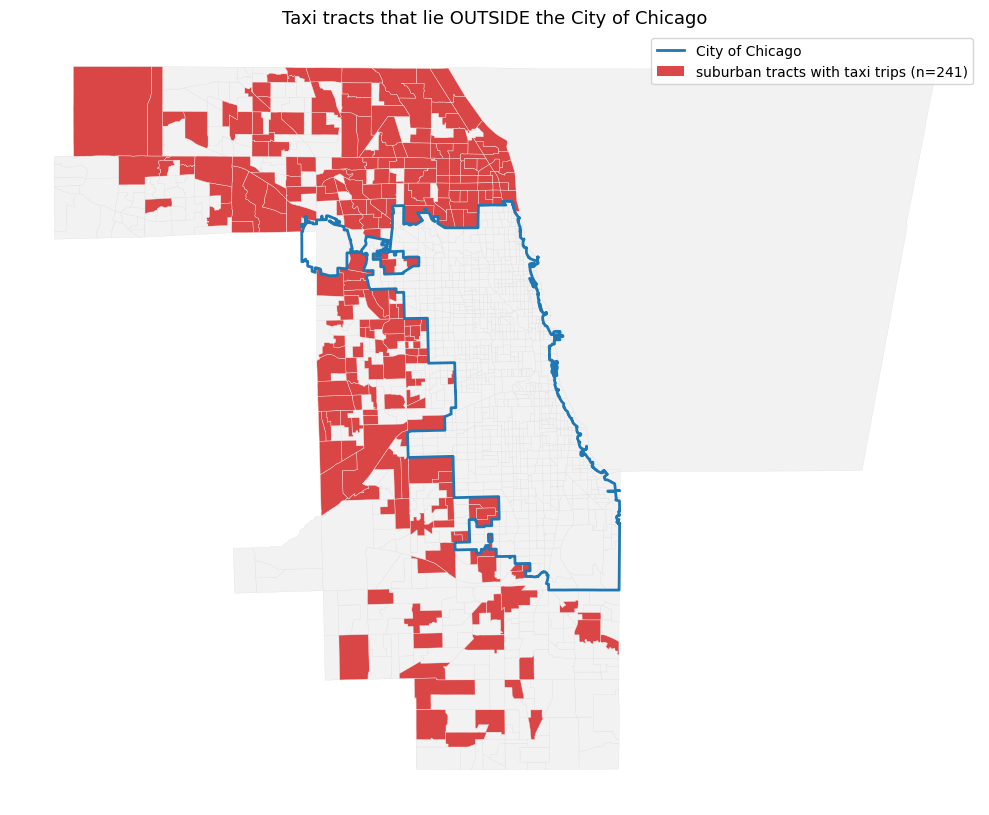

[Step 1] trips with no usable location:   609,494 (8.93% of all raw trips)
[Step 2] of 6,216,344 located trips:
         pickups outside city:   841 (0.01%)
         dropoffs outside city:  6,631 (0.11%)
         start OR end outside:   6,673 (0.11%)


In [15]:
# tracts that appear in the data, restricted to suburban (outside-city) ones
outside_tracts = sorted(t for t in taxi_tracts
                        if t in set(tracts2010["GEOID"]) and t not in in_city_2010)
out_gdf = tracts2010[tracts2010["GEOID"].isin(outside_tracts)]

fig, ax = plt.subplots(figsize=(10, 12))
tracts2010.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#dcdcdc", linewidth=0.2)
out_gdf.plot(ax=ax, facecolor="#d62728", edgecolor="white", linewidth=0.3, alpha=0.85)
gpd.GeoSeries([city_poly], crs=4326).plot(ax=ax, facecolor="none", edgecolor="#1f77b4", linewidth=2)
ax.legend(handles=[
    Line2D([0], [0], color="#1f77b4", lw=2, label="City of Chicago"),
    Patch(facecolor="#d62728", alpha=0.85,
          label=f"suburban tracts with taxi trips (n={len(outside_tracts)})")], loc="upper right")
ax.set_title("Taxi tracts that lie OUTSIDE the City of Chicago", fontsize=13)
ax.set_axis_off()
plt.tight_layout(); plt.show()


# An endpoint is "locatable" if it has ANY of tract / community area / coordinates.
def locatable(prefix):
    return (df[f"{prefix}_census_tract"].notna()
            | df[f"{prefix}_community_area"].notna()
            | df[f"{prefix}_centroid_latitude"].notna())

# An endpoint is "inside" only when a signal positively places it in the city.
def inside_series(prefix):
    tract = df[f"{prefix}_census_tract"]
    ca    = pd.to_numeric(df[f"{prefix}_community_area"], errors="coerce")
    lat, lon = df[f"{prefix}_centroid_latitude"], df[f"{prefix}_centroid_longitude"]
    inside = ca.between(1, 77)                                   # (a) valid CA -> inside
    need = ~inside & tract.notna()                               # (b) tract -> CA crosswalk
    inside.loc[need] = tract[need].map(tract_to_ca).notna()
    need = ~inside & tract.isna() & lat.notna()                  # (c) point-in-city
    if need.any():
        pts = gpd.GeoSeries(gpd.points_from_xy(lon[need], lat[need]), crs=4326)
        inside.loc[need] = pts.within(city_poly).values
    return inside.fillna(False)

p_loc, d_loc = locatable("pickup"), locatable("dropoff")
p_in,  d_in  = inside_series("pickup"), inside_series("dropoff")

# Step 1 — no usable location at all (handled FIRST, separate from "outside")
no_loc = ~(p_loc & d_loc)
print(f"[Step 1] trips with no usable location:   {int(no_loc.sum()):,} "
      f"({no_loc.mean()*100:.2f}% of all raw trips)")

# Step 2 — of the trips that DO have a location, which start/end outside the city
located = p_loc & d_loc
n_loc   = int(located.sum())
pu_out  = int((located & ~p_in).sum())
do_out  = int((located & ~d_in).sum())
out_trips = int((located & (~p_in | ~d_in)).sum())
print(f"[Step 2] of {n_loc:,} located trips:")
print(f"         pickups outside city:   {pu_out:,} ({pu_out / n_loc * 100:.2f}%)")
print(f"         dropoffs outside city:  {do_out:,} ({do_out / n_loc * 100:.2f}%)")
print(f"         start OR end outside:   {out_trips:,} ({out_trips / n_loc * 100:.2f}%)")

**Reading.** Keep the two removals apart. **Step 1** drops the trips that have *no usable location at all* (≈9–10 % of raw trips, dominated by missing dropoffs) — they can't be placed, so they are unusable rather than "outside". **Step 2**, looking only at trips that *do* have a location, finds that **well under 1 %** start or end outside the city (dropoffs leave ~10× more than pickups). Dropping those costs almost nothing while removing a real source of error. The **hole** on the North-West Side is the **Norridge + Harwood Heights** enclave — two independent suburbs fully surrounded by Chicago, which correctly fall outside every community area. 
→ **Drop no-location trips first, then drop trips that start or end outside Chicago.**

## 4  From tracts to community areas — the robust common unit

Because the tract is suppressed in low-volume areas, the only level present for ~all trips is the **community area**. Aggregating to the 77 community areas keeps ~97 % of trips with no imputation, where a tract grid keeps ~45 %. Below is the trip volume per community area, which also shows where taxi demand actually concentrates.

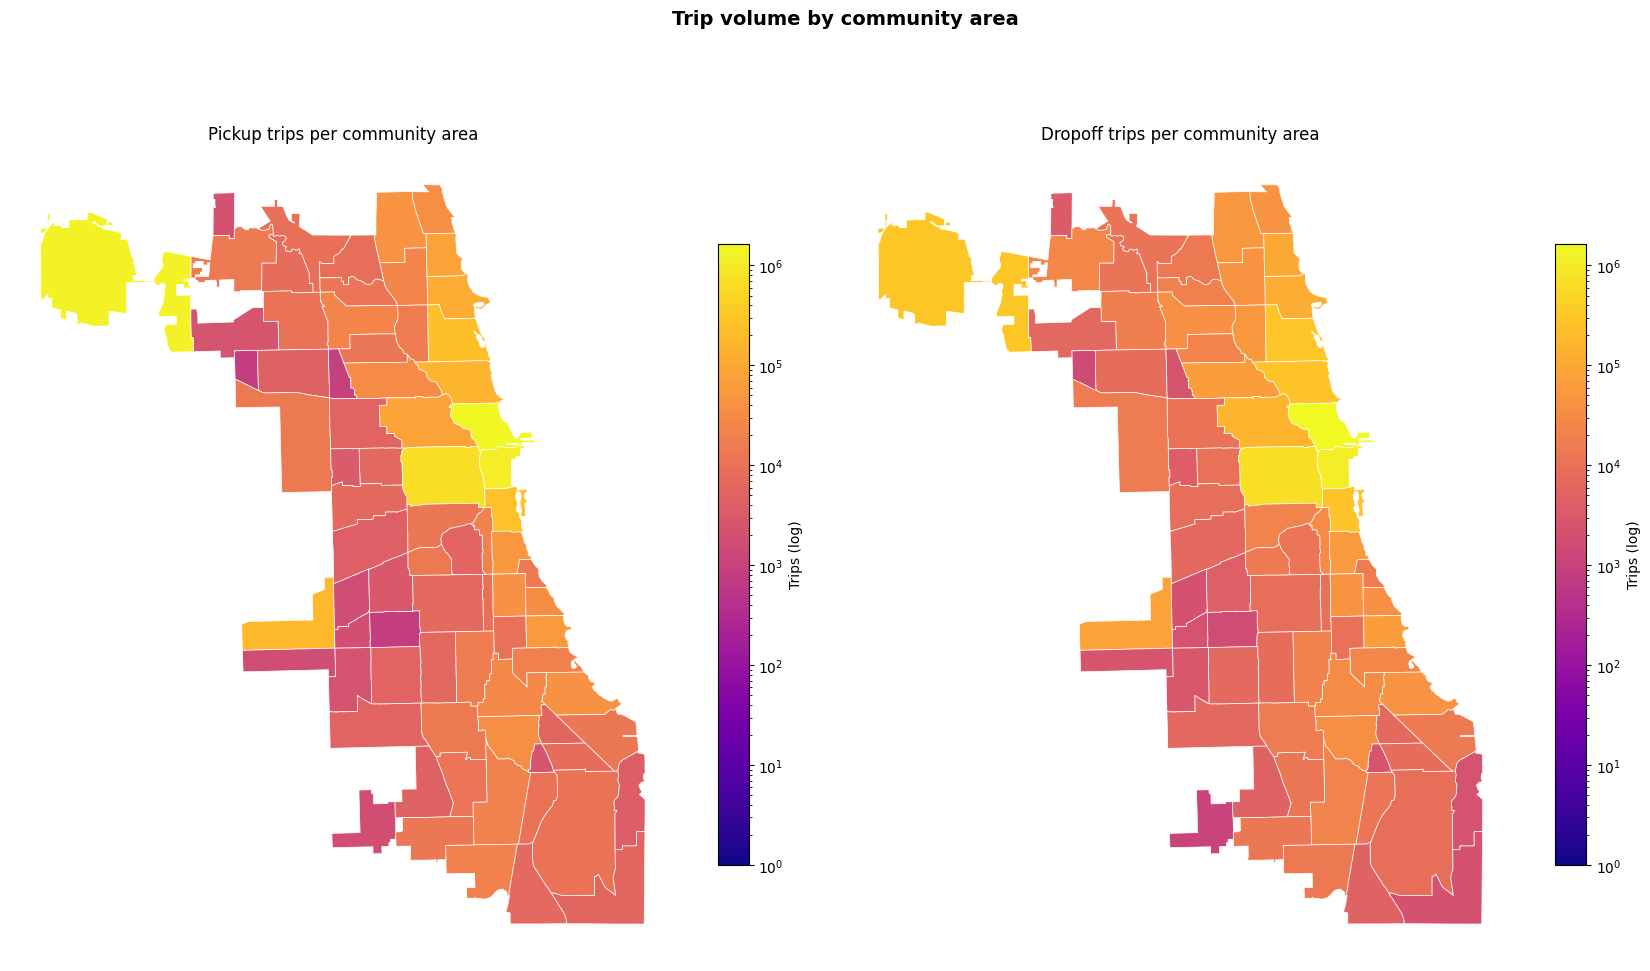

In [16]:
ca_counts = {}
for prefix in ("pickup", "dropoff"):
    c = pd.to_numeric(df[f"{prefix}_community_area"], errors="coerce").dropna().astype(int)
    ca_counts[prefix] = c.value_counts()

vmax = max(ca_counts["pickup"].max(), ca_counts["dropoff"].max())
fig, axes = plt.subplots(1, 2, figsize=(17, 11))
for ax, prefix in zip(axes, ("pickup", "dropoff")):
    g = community_areas.copy()
    g["count"] = g["community_area"].map(ca_counts[prefix]).fillna(0)
    g.plot(ax=ax, column="count", cmap="plasma", norm=LogNorm(vmin=1, vmax=vmax),
           edgecolor="white", linewidth=0.5, legend=True,
           legend_kwds={"label": "Trips (log)", "shrink": 0.6})
    ax.set_title(f"{prefix.capitalize()} trips per community area", fontsize=12)
    ax.set_axis_off()
plt.suptitle("Trip volume by community area", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

**Reading.** Volume is dominated by the downtown core (Near North, Loop, Near West) and the airports. O'Hare (76) shows the strongest pickup↔dropoff asymmetry — far more people *catch* a cab there than are dropped off. This confirms community area as a stable, fully-populated unit, and gives us the tract→community-area crosswalk used to fill any missing community area.

## 5  Building the H3 grid: centroid vs area-weighted

H3 hexagons don't nest in tracts or community areas, so we must turn each trip's *area-level*
location into a *cell*. Two strategies:

* **Centroid mapping** — send the trip to the H3 cell containing its reported coordinate. Simple,
  but the coordinate is only the **centroid** of its tract or community area, so every trip in an
  area collapses onto a single point. With ~52 % of trips anonymised to just 77 community-area
  centroids, this lights up a handful of cells and leaves the rest empty.
* **Area-weighted mapping** — for each community area, split its trips across the H3 cells that
  cover it, weighted by overlap area. This spreads trips realistically and never crosses
  community-area / city boundaries.

We build both at **resolutions 6 and 7** and compare.

In [17]:
# Clean working set: in-city trips with a resolvable community area (mirrors steps 1-4)
work = df[(p_in & d_in)].copy()
for prefix in ("pickup", "dropoff"):
    has = (work[f"{prefix}_census_tract"].notna()
           | work[f"{prefix}_community_area"].notna()
           | work[f"{prefix}_centroid_latitude"].notna())
    work = work[has]

for prefix in ("pickup", "dropoff"):
    ca_col = f"{prefix}_community_area"
    work[ca_col] = pd.to_numeric(work[ca_col], errors="coerce")
    need = work[ca_col].isna() & work[f"{prefix}_census_tract"].notna()
    work.loc[need, ca_col] = work.loc[need, f"{prefix}_census_tract"].map(tract_to_ca).values
    need = work[ca_col].isna() & work[f"{prefix}_centroid_latitude"].notna()
    if need.any():
        pts = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(work.loc[need, f"{prefix}_centroid_longitude"],
                                        work.loc[need, f"{prefix}_centroid_latitude"]),
            crs=4326, index=work.index[need])
        j = gpd.sjoin(pts, community_areas[["community_area", "geometry"]], how="left", predicate="within")
        j = j[~j.index.duplicated()]
        work.loc[j.index, ca_col] = j["community_area"].values

work = work.dropna(subset=["pickup_community_area", "dropoff_community_area"])
work["pickup_community_area"]  = work["pickup_community_area"].astype(int)
work["dropoff_community_area"] = work["dropoff_community_area"].astype(int)
print(f"Clean in-city trips for the H3 comparison: {len(work):,}")

Clean in-city trips for the H3 comparison: 6,209,671


In [18]:
H3_RESOLUTIONS = [6, 7]

# --- (B) area-weighted coverage per community area ---
def build_ca_hex_coverage(ca_gdf, res):
    rows = []
    for _, row in ca_gdf.iterrows():
        cid, geom = row["community_area"], row.geometry
        parts = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
        cells = set()
        for p in parts:
            cells.update(h3.geo_to_cells(p.__geo_interface__, res))
        if not cells:
            c = geom.centroid; cells = {h3.latlng_to_cell(c.y, c.x, res)}
        cand = set(cells)
        for cell in cells:
            cand.update(h3.grid_disk(cell, 1))
        for cell in cand:
            hp = Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            a = geom.intersection(hp).area
            if a > 0:
                rows.append({"community_area": cid, "h3_cell": cell, "area": a})
    cov = pd.DataFrame(rows)
    cov["weight"] = cov["area"] / cov.groupby("community_area")["area"].transform("sum")
    return cov

rng = np.random.default_rng(42)

# We keep only per-cell trip counts (not per-trip arrays) to stay memory-light.
def centroid_counts(prefix, res):
    lat = work[f"{prefix}_centroid_latitude"].to_numpy()
    lon = work[f"{prefix}_centroid_longitude"].to_numpy()
    cells = [h3.latlng_to_cell(la, lo, res) for la, lo in zip(lat, lon) if la == la and lo == lo]
    return pd.Series(cells).value_counts()

def weighted_counts(prefix, lookup):
    parts = []
    for cid, idx in work.groupby(f"{prefix}_community_area").groups.items():
        if cid not in lookup:
            continue
        cells, w = lookup[cid]
        parts.append(pd.Series(rng.choice(cells, size=len(idx), p=w)))
    return pd.concat(parts).value_counts()

# counts keyed by (resolution, direction, method)
counts = {}
for res in H3_RESOLUTIONS:
    cov = build_ca_hex_coverage(community_areas, res)
    lookup = {cid: (g["h3_cell"].values, g["weight"].values)
              for cid, g in cov.groupby("community_area")}
    for direction in ("pickup", "dropoff"):
        counts[(res, direction, "centroid")] = centroid_counts(direction, res)
        counts[(res, direction, "weighted")] = weighted_counts(direction, lookup)
    print(f"resolution {res}: " + "  |  ".join(
        f"{d}/{m} {len(counts[(res, d, m)])} cells"
        for d in ("pickup", "dropoff") for m in ("centroid", "weighted")))

resolution 6: pickup/centroid 27 cells  |  pickup/weighted 33 cells  |  dropoff/centroid 27 cells  |  dropoff/weighted 33 cells
resolution 7: pickup/centroid 119 cells  |  pickup/weighted 160 cells  |  dropoff/centroid 119 cells  |  dropoff/weighted 160 cells


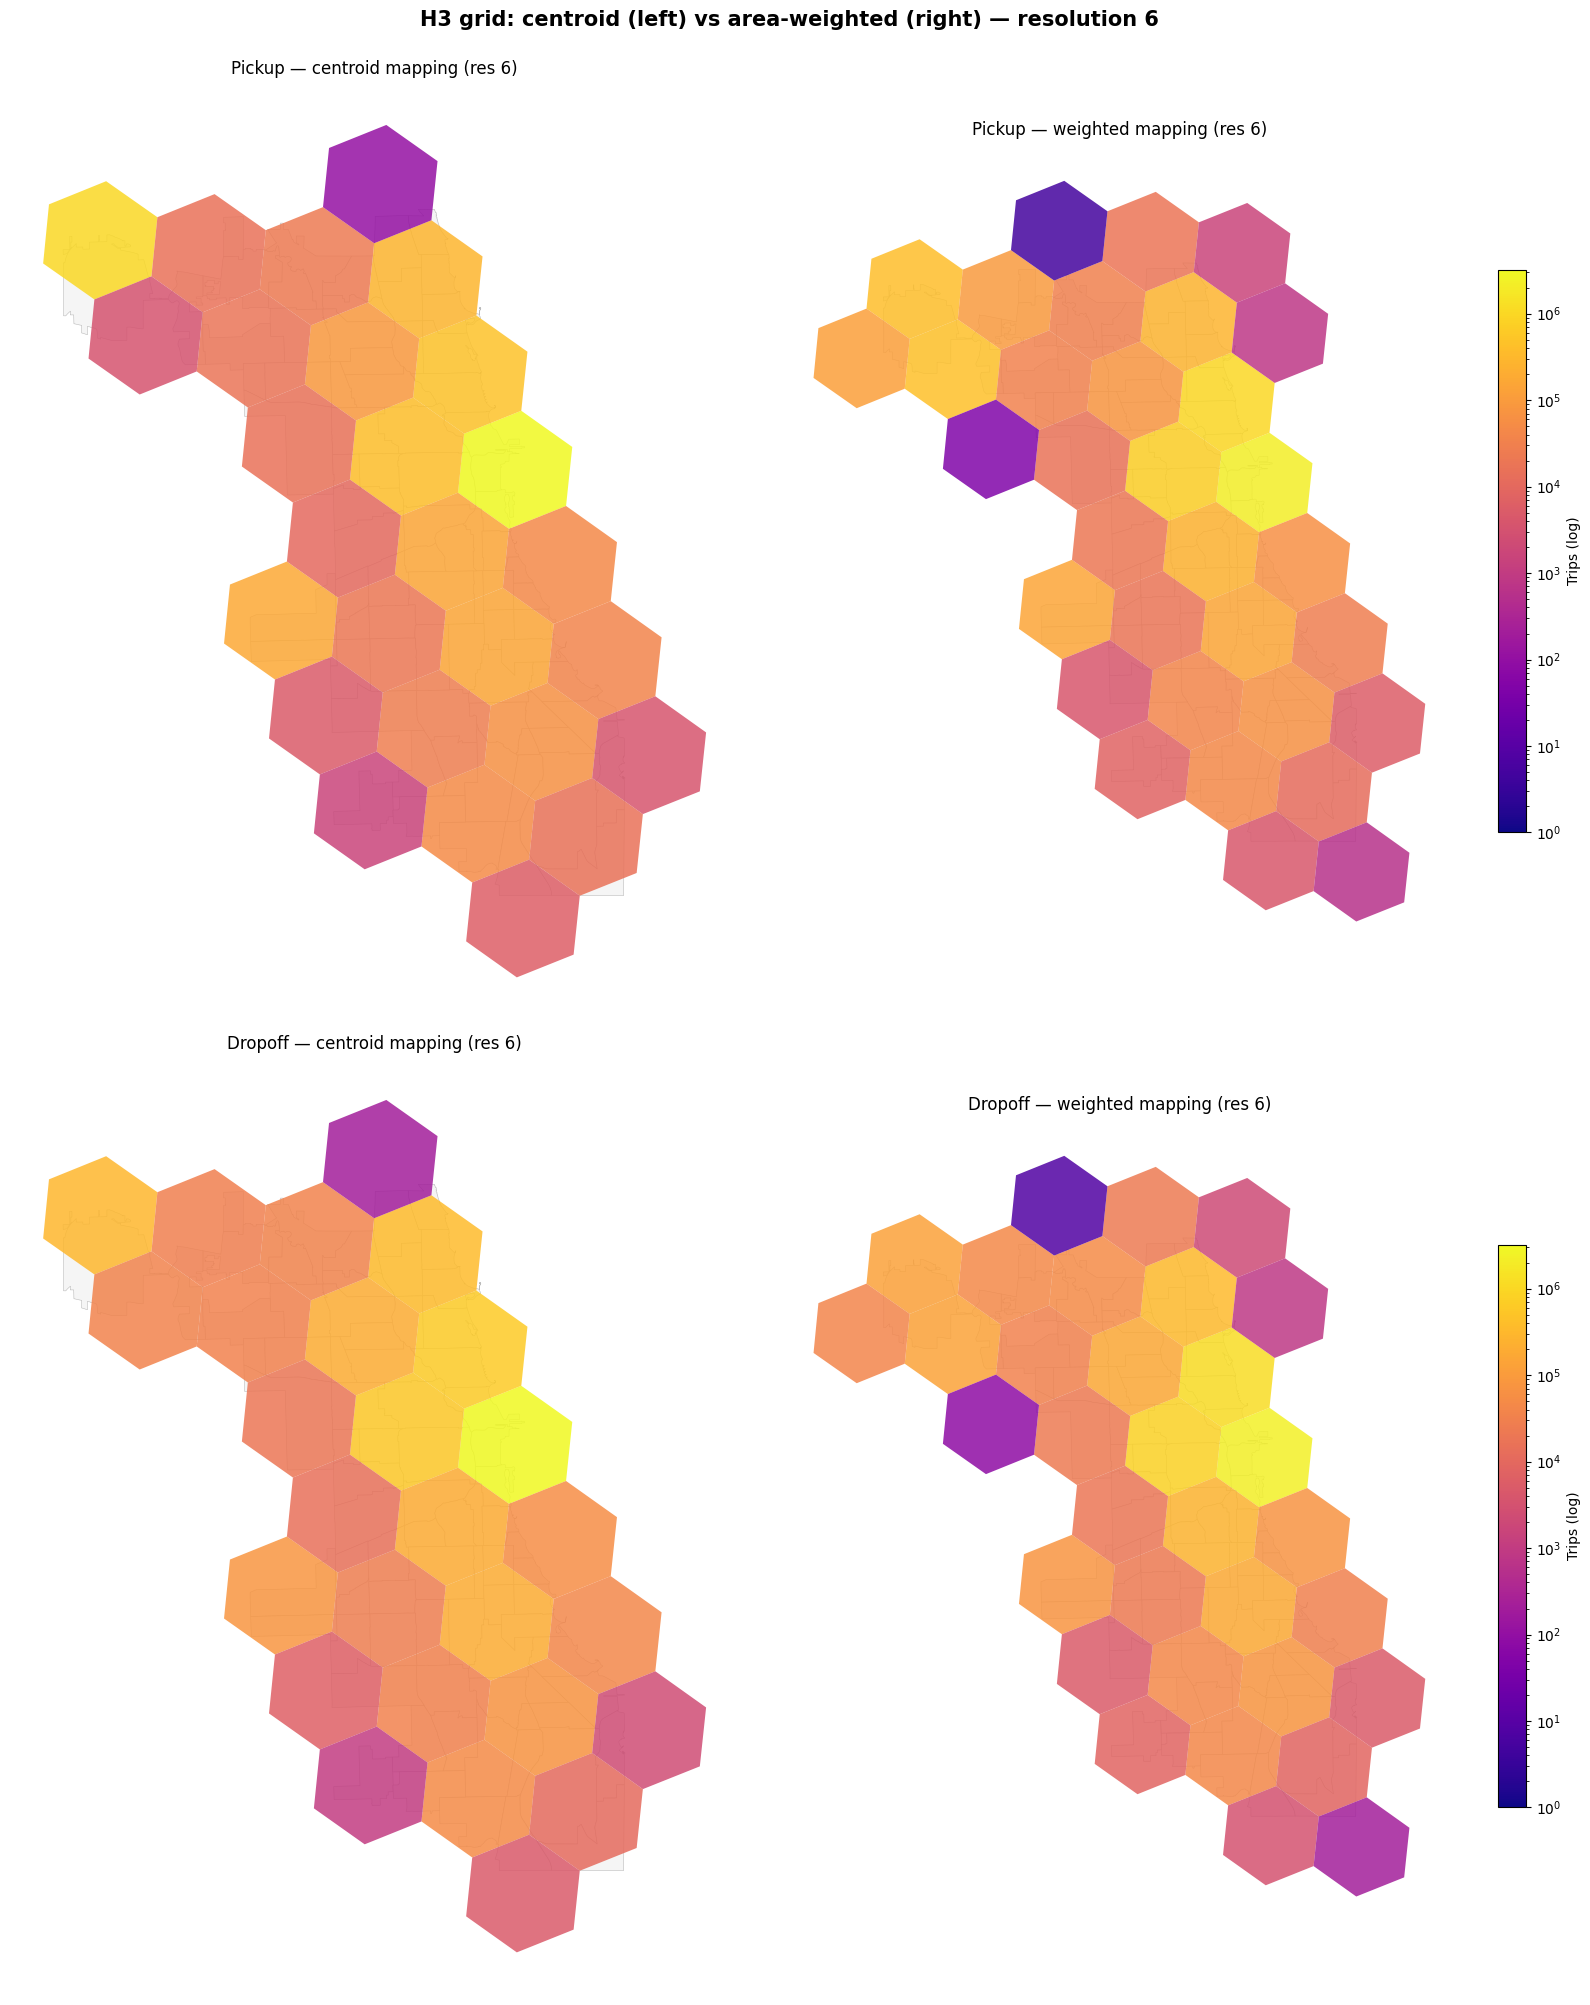

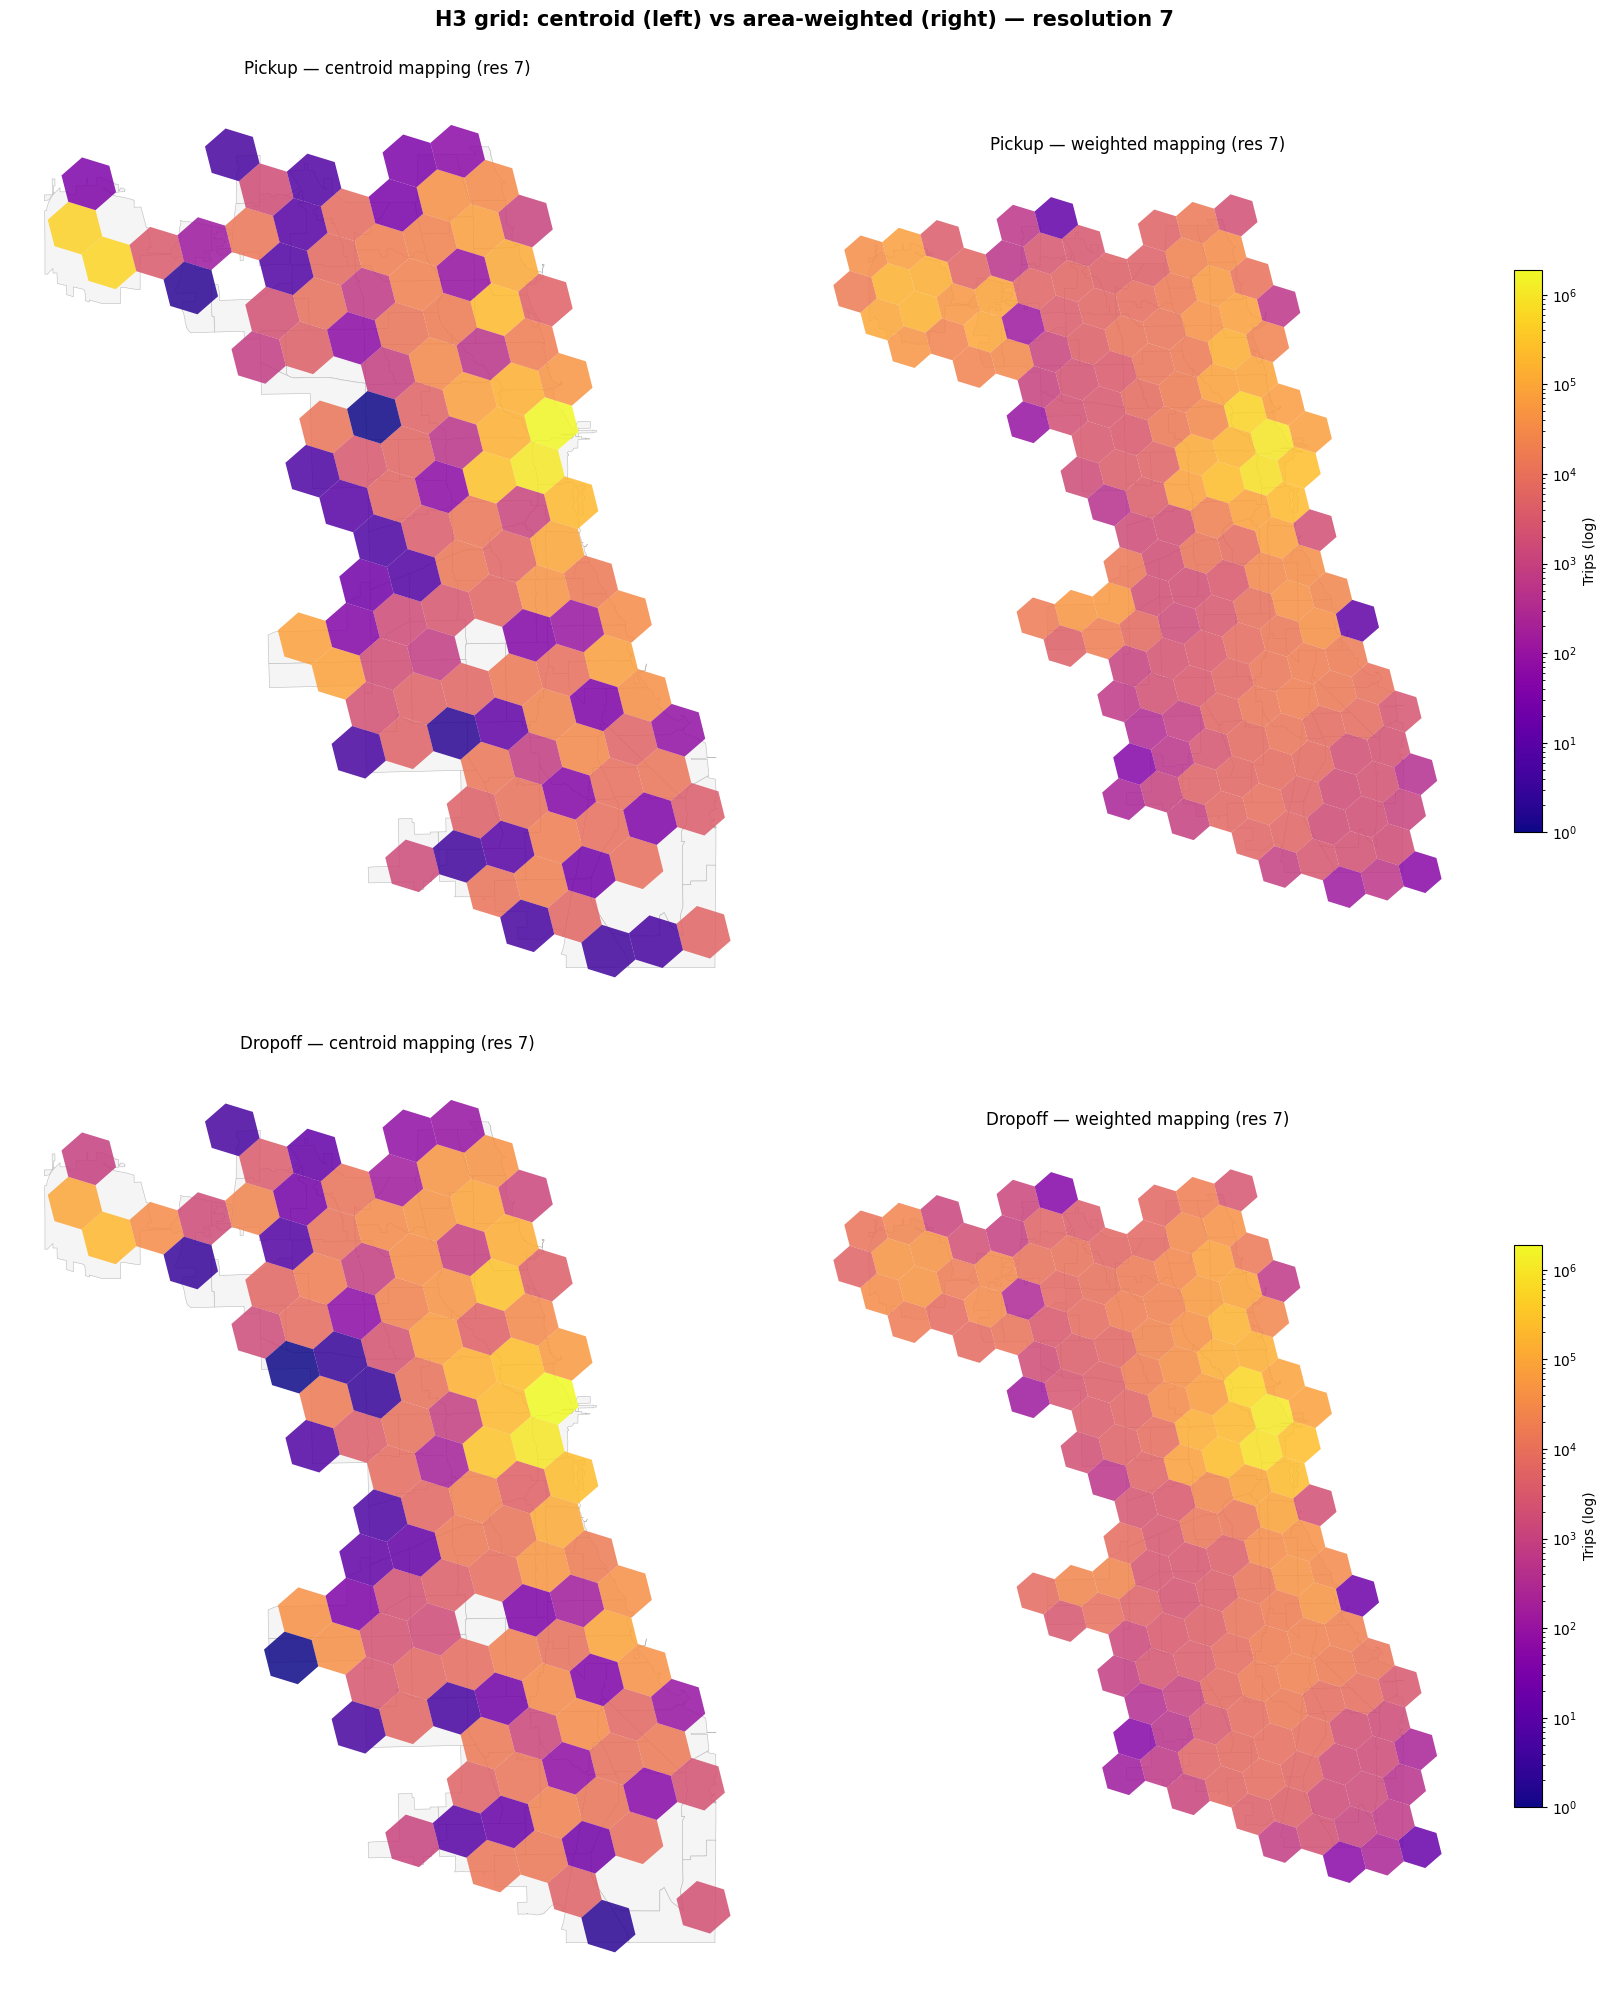

In [19]:
def hex_gdf_from(counts_series):
    polys = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)]) for c in counts_series.index]
    return gpd.GeoDataFrame({"count": counts_series.values, "geometry": polys}, crs=4326)

# one 2x2 figure per resolution: rows = pickup/dropoff, cols = centroid/weighted
for res in H3_RESOLUTIONS:
    sub = {k: v for k, v in counts.items() if k[0] == res}
    vmax = max(v.max() for v in sub.values())
    fig, axes = plt.subplots(2, 2, figsize=(17, 20))
    for r, direction in enumerate(("pickup", "dropoff")):
        for c, method in enumerate(("centroid", "weighted")):
            ax = axes[r, c]
            hg = hex_gdf_from(counts[(res, direction, method)])
            community_areas.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#bbbbbb", linewidth=0.4)
            hg.plot(ax=ax, column="count", cmap="plasma", norm=LogNorm(vmin=1, vmax=vmax),
                    legend=(c == 1), legend_kwds={"label": "Trips (log)", "shrink": 0.6},
                    edgecolor="none", alpha=0.85)
            ax.set_title(f"{direction.capitalize()} — {method} mapping (res {res})", fontsize=12)
            ax.set_axis_off()
    plt.suptitle(f"H3 grid: centroid (left) vs area-weighted (right) — resolution {res}",
                 fontsize=15, fontweight="bold", y=1.0)
    plt.tight_layout(); plt.show()

**Reading.** The **centroid** maps (left) are a scatter of isolated bright hexagons — every community-area-only trip lands on the same 77 centroid points, and tract-level trips clump on their tract centroids, leaving most cells empty (note how few distinct cells they use and how much mass sits in the single top cell). The **area-weighted** maps (right) fill each community area smoothly and stay within its boundary, giving a realistic surface for modelling.
→ **We build the H3 grid with the area-weighted approach.**

## Summary — spatial cleanup decisions and their justification

| Step | Decision | Why (evidence above) |
|---|---|---|
| Resolution | Treat community area as the common unit | Only ~45 % of endpoints have a tract; ~52 % are community-area only (§1) |
| Tract vintage | Use `tl_2010_17031_tract10`, not the 2000 geojson | 2010 IDs match the data; the 2000 join drops ~190 tracts of coverage (§2) |
| No location | Drop trips with no tract / community area / coordinate | ≈9–10 % of raw trips cannot be placed at all (§3, Step 1) |
| City filter | Drop trips starting/ending outside Chicago | <1 % of *located* trips; suburban tracts + Norridge/Harwood Heights enclave (§3, Step 2) |
| Community area | Fill missing CA from the 2010 tract crosswalk | CA is complete & authoritative; keeps ~97 % of trips (§4) |
| H3 grid | Area-weighted within community area, resolutions 7 & 8 | Centroid mapping collapses ~52 % of trips onto a few centroid cells (§5) |

These are exactly the steps implemented in `01_Preprocessing/01_04_Trip_Data_Cleanup.ipynb`.